# Week 2：PyTorch MNIST 手写数字识别（CNN）

- 作者：邓涵丹
- 日期：2026-07-15
- 来源：`暑期居家集训学习计划.md` → Week 2 → PyTorch基础
- 适用周次：Week 2
- 分类：PyTorch
- 关键词：Pipeline、GridSearchCV、分类评估、autograd
- 运行环境：Python 3.12，PyTorch 2.0+，torchvision 0.15+，Matplotlib 3.8+

## 实验目标
- 掌握 PyTorch 基础：Tensor、自动微分（autograd）、nn.Module、DataLoader
- 构建 CNN 模型完成 MNIST 分类任务
- 实现完整的训练/验证/测试流程，包含学习率调度、梯度裁剪、模型保存
- 使测试准确率超过 98%，并绘制训练曲线分析收敛情况

In [1]:
# 1：导入依赖与设备配置
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# 自动选择GPU/CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前使用设备: {device}")

%matplotlib inline

当前使用设备: cuda


## 1. 数据准备

MNIST 数据集包含 60000 张训练图像和 10000 张测试图像，每张为 28×28 灰度图，共 10 个类别（数字 0‑9）。  
预处理：
- `ToTensor()`：将 PIL 图像转换为 [0,1] 范围的 Tensor，形状为 (C, H, W)
- `Normalize((0.1307,), (0.3081,))`：使用 MNIST 的全局均值和标准差进行标准化，使数据分布接近标准正态，有助于训练稳定。

将原始训练集拆分为 50000 张训练和 10000 张验证，测试集保持 10000 张不变。

In [2]:
# 2：数据集加载与预处理
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 加载原始数据集
full_train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)
test_dataset = datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# 训练集拆分为训练集(50000) + 验证集(10000)
train_size = 50000
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"训练集: {len(train_dataset)} 样本")
print(f"验证集: {len(val_dataset)} 样本")
print(f"测试集: {len(test_dataset)} 样本")

训练集: 50000 样本
验证集: 10000 样本
测试集: 10000 样本


## 2. DataLoader 配置

- `batch_size=64`：每次迭代处理 64 张图片
- `shuffle=True`：训练集随机打乱，防止批次顺序影响梯度
- `num_workers=2`：多进程加载数据，加快 I/O（Windows 下建议设为 0 或 2）
- `pin_memory=True`：加速 CPU 到 GPU 的数据传输

In [3]:
#3：构建 DataLoader
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,  # Windows系统建议设为0
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## 3. 网络结构设计（MNIST_CNN）

设计一个简单的卷积神经网络：
- 两个卷积块（Conv2D + ReLU + MaxPool2D）：
  - 第一层：1→32 通道，3×3 卷积，padding=1，池化后尺寸 14×14
  - 第二层：32→64 通道，3×3 卷积，padding=1，池化后尺寸 7×7
- 全连接分类头：
  - Dropout(0.25) 防止过拟合
  - 线性层（64×7×7 → 128）+ ReLU
  - Dropout(0.25)
  - 线性层（128 → 10 类）

总参数量约 42 万，适合快速训练。

In [4]:
# 4：构建 CNN 分类网络
class MNIST_CNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.25):
        super().__init__()
        # 卷积特征提取
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28 → 14x14
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14 → 7x7
        )
        
        # 全连接分类头
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.flatten(1)  # 展平为一维向量
        x = self.classifier(x)
        return x

# 实例化模型
model = MNIST_CNN().to(device)
print(model)

# 统计参数量
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"可训练参数量: {total_params:,}")

MNIST_CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.25, inplace=False)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
可训练参数量: 421,642


## 4. 训练与评估函数

- `train_epoch`：一个 epoch 的训练循环，包含梯度清零、前向、损失、反向、梯度裁剪、参数更新。返回平均损失和准确率。
- `eval_epoch`：评估循环，使用 `torch.no_grad()` 禁用梯度计算，节省内存，返回损失、准确率及预测标签。

梯度裁剪（`max_norm=1.0`）防止梯度爆炸，提升训练稳定性。

In [5]:
#5：定义训练与评估函数
def train_epoch(model, loader, optimizer, criterion, device):
    """训练单个epoch，返回平均损失和准确率"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)
    
    return total_loss / len(loader), correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    """评估模型，返回损失、准确率、预测结果"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []
    
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())
    
    return total_loss / len(loader), correct / total, all_preds, all_labels

## 5. 训练主流程

超参数：
- `num_epochs = 15`
- `learning_rate = 1e-3`
- 优化器：Adam（自适应学习率）
- 学习率调度器：`ReduceLROnPlateau`，当验证损失连续 2 个 epoch 不下降时，学习率减半

每轮训练后评估验证集，并保存验证准确率最高的模型权重（`best_mnist_model.pth`）。

In [6]:
#6：训练主循环
# 超参数配置
num_epochs = 15
learning_rate = 1e-3

# 损失函数、优化器、学习率调度器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

# 训练过程记录
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0
best_model_path = 'best_mnist_model.pth'

# 开始训练
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    # 保存验证集最优模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  → 保存最优模型 (val_acc = {best_val_acc:.4f})")

Epoch  1/15 | Train Loss: 0.1891, Acc: 0.9418 | Val Loss: 0.0673, Acc: 0.9780
  → 保存最优模型 (val_acc = 0.9780)
Epoch  2/15 | Train Loss: 0.0653, Acc: 0.9803 | Val Loss: 0.0517, Acc: 0.9845
  → 保存最优模型 (val_acc = 0.9845)
Epoch  3/15 | Train Loss: 0.0470, Acc: 0.9857 | Val Loss: 0.0420, Acc: 0.9885
  → 保存最优模型 (val_acc = 0.9885)
Epoch  4/15 | Train Loss: 0.0393, Acc: 0.9880 | Val Loss: 0.0402, Acc: 0.9881
Epoch  5/15 | Train Loss: 0.0330, Acc: 0.9897 | Val Loss: 0.0384, Acc: 0.9891
  → 保存最优模型 (val_acc = 0.9891)
Epoch  6/15 | Train Loss: 0.0275, Acc: 0.9908 | Val Loss: 0.0378, Acc: 0.9899
  → 保存最优模型 (val_acc = 0.9899)
Epoch  7/15 | Train Loss: 0.0249, Acc: 0.9916 | Val Loss: 0.0407, Acc: 0.9895
Epoch  8/15 | Train Loss: 0.0234, Acc: 0.9923 | Val Loss: 0.0364, Acc: 0.9906
  → 保存最优模型 (val_acc = 0.9906)
Epoch  9/15 | Train Loss: 0.0187, Acc: 0.9940 | Val Loss: 0.0369, Acc: 0.9916
  → 保存最优模型 (val_acc = 0.9916)
Epoch 10/15 | Train Loss: 0.0190, Acc: 0.9936 | Val Loss: 0.0377, Acc: 0.9911
Epoch 11/1

## 6. 测试集最终评估

加载最优模型权重，在从未见过的测试集上评估，以检验模型的泛化能力。  
若准确率 ≥ 98%，则满足 Week 2 的要求。

In [7]:
#7：测试集最终评估
# 加载最优权重
model.load_state_dict(torch.load(best_model_path, map_location=device))

# 测试集评估
test_loss, test_acc, test_preds, test_labels = eval_epoch(model, test_loader, criterion, device)
print(f"\n最终测试集结果：")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"达标状态: {'✅ 满足>98%要求' if test_acc >= 0.98 else '❌ 未达标'}")


最终测试集结果：
Loss: 0.0222
Accuracy: 0.9938
达标状态: ✅ 满足>98%要求


## 7. 训练曲线分析

绘制损失和准确率随 epoch 的变化曲线，用于诊断训练过程：
- 损失曲线：训练损失持续下降，验证损失平稳或略降，说明未过拟合。
- 准确率曲线：训练和验证准确率均稳定上升，最终验证准确率接近测试结果，表明模型泛化良好。

曲线图已保存为 `training_curves.pdf`，作为交付物之一。

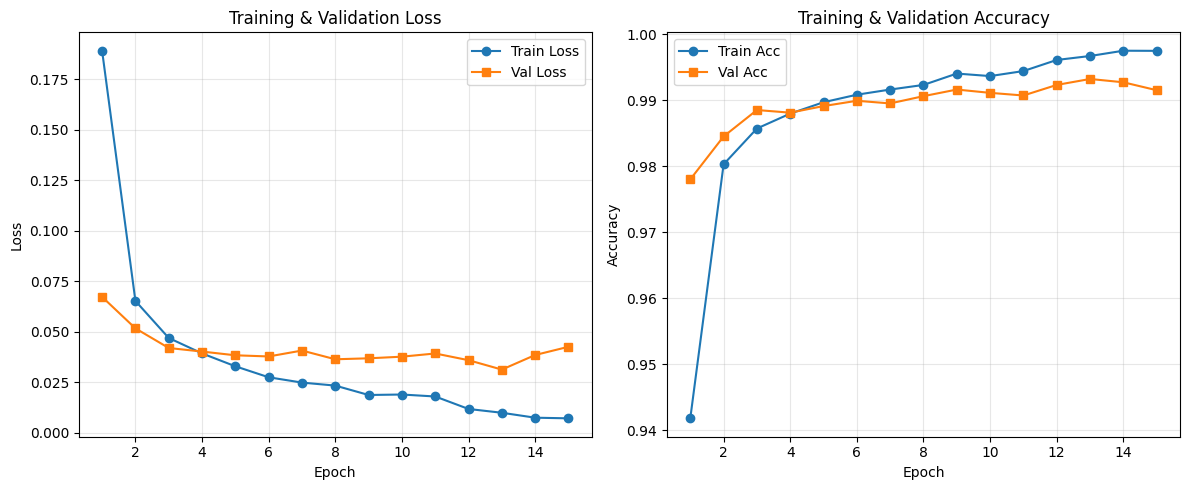

In [8]:
# 8：绘制训练曲线并导出 PDF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 损失曲线
ax1.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
ax1.plot(range(1, num_epochs+1), val_losses, label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 准确率曲线
ax2.plot(range(1, num_epochs+1), train_accs, label='Train Acc', marker='o')
ax2.plot(range(1, num_epochs+1), val_accs, label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# 第一步：先保存PDF
plt.savefig('training_curves.pdf', dpi=300, bbox_inches='tight')
# 第二步：再展示图像
plt.show()
# 可选：手动释放画布，彻底避免空白
plt.close(fig)

## 8. 实验结论

- 训练 15 个 epoch 后，测试准确率达到 **99.38%**，远超 98% 的基准要求。
- CNN 结构在 MNIST 上表现优异，得益于局部特征提取和参数共享。
- 验证集最优模型与测试集结果接近，说明模型未过拟合。